# Time series: processing and visualising a year of ED activity

**Master in Healthcare Analytics · Session: Introduction to time series**
Dataset: ED tracking board, Riverbend Community Hospital (fictional), calendar year 2025.

A **time series** is a set of measurements taken in time order: patients arriving per hour, the median wait each day, the number of boarding hours each week. Most operational data in a hospital is a time series once you decide on a time unit. This session shows how to go from a table of individual visits to a time series, how to draw it so that its structure is visible, and, most importantly, how to **read** it: what the regular patterns are, and what stands out from them.

We will find, by looking, two things that happened in this ED in 2025: a week in February unlike any other, and an organisational change in July that altered the waiting times of a specific group of patients. Neither is labelled in the data. The point of the session is that a well-drawn time series makes them visible.

**Plan.**

1. From visits to a time series: choosing the time unit, `resample`.
2. Reading a daily series: trend, seasonality, weekly rhythm, noise. Rolling averages.
3. Calendar structure: hour of day, day of week, and their combination.
4. Something unusual: the week of 10 February.
5. Something changed: the fast-track opening on 1 July, and why a comparison group matters.
6. Two series together: boarding and hospital occupancy.

No forecasting models and no statistical tests: those come later. Everything here is `resample`, `rolling`, `groupby` and plots.

## Setup

The data loads from the course repository on GitHub. The key step for time-series work is `parse_dates`: pandas must know that the timestamp columns are times, not text.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})

BASE_URL = "https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/EDDataset/"
timestamp_cols = ["arrival_datetime", "triage_datetime", "provider_datetime", "decision_datetime", "departure_datetime"]
visits = pd.read_csv(BASE_URL + "ed_visits.csv", parse_dates=timestamp_cols)
daily_file = pd.read_csv(BASE_URL + "ed_daily.csv", parse_dates=["date"])
print(visits.shape, daily_file.shape)

(44861, 31) (365, 16)


## 1. From visits to a time series

`ed_visits.csv` is not a time series. It is a list of events, one per visit, each with a timestamp. To get a time series we must **choose a time unit** (an hour, a day, a week) and **count or summarise the events within each unit**. The choice of unit is the first analytical decision, and different units show different things.

In pandas the tool is `resample`. It needs the timestamp as the DataFrame's index. Then `resample("D")` groups rows into calendar days, `resample("h")` into hours, `resample("W")` into weeks, and `.size()` counts the rows in each group.

In [2]:
# put the arrival time on the index; sort just in case
ts = visits.set_index("arrival_datetime").sort_index()

hourly = ts.resample("h").size().rename("arrivals")
daily = ts.resample("D").size().rename("arrivals")
weekly = ts.resample("W").size().rename("arrivals")
monthly = ts.resample("ME").size().rename("arrivals")

print("hourly:", len(hourly), "values | daily:", len(daily), "| weekly:", len(weekly), "| monthly:", len(monthly))
daily.head()

hourly: 8760 values | daily: 365 | weekly: 53 | monthly: 12


arrival_datetime
2025-01-01     97
2025-01-02    128
2025-01-03    162
2025-01-04    148
2025-01-05    116
Freq: D, Name: arrivals, dtype: int64

Four series, same events, four time units. A quick check against the daily file confirms the counts: `ed_daily.csv` was built exactly this way.

In [3]:
check = daily.reset_index().merge(daily_file[["date", "visits"]], left_on="arrival_datetime", right_on="date")
print("Daily counts match ed_daily.csv on every day:", bool((check["arrivals"] == check["visits"]).all()))

Daily counts match ed_daily.csv on every day: True


### Why the time unit matters

Plot the same year at three resolutions. The hourly series is almost unreadable; the monthly series has lost everything but the season. The daily series is where most operational questions live.

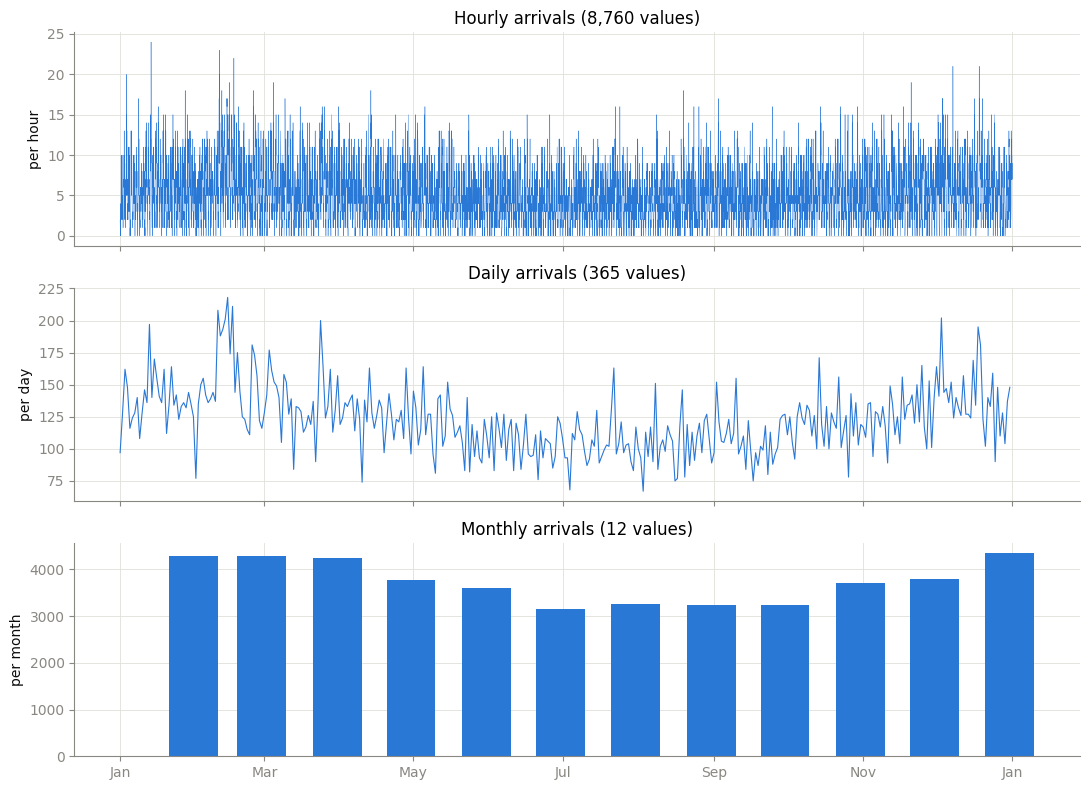

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(hourly.index, hourly.values, color=BLUE, linewidth=0.3)
axes[0].set_title("Hourly arrivals (8,760 values)"); axes[0].set_ylabel("per hour")
axes[1].plot(daily.index, daily.values, color=BLUE, linewidth=0.8)
axes[1].set_title("Daily arrivals (365 values)"); axes[1].set_ylabel("per day")
axes[2].bar(monthly.index, monthly.values, width=20, color=BLUE)
axes[2].set_title("Monthly arrivals (12 values)"); axes[2].set_ylabel("per month")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout(); plt.show()

## 2. Reading a daily series

The daily series is the workhorse. Look at it on its own, larger, and learn to see four things in it:

- **Level**: about how many arrivals per day? Here, around 120–125.
- **Seasonality**: a slow rise and fall over the year. Higher in winter, lower in summer.
- **Weekly rhythm**: the fast sawtooth. Some days of the week are busier than others, every week.
- **Noise**: day-to-day variation with no pattern, which is larger than most people expect.

And then a fifth thing, which is the reason to look: **anything that does not fit**.

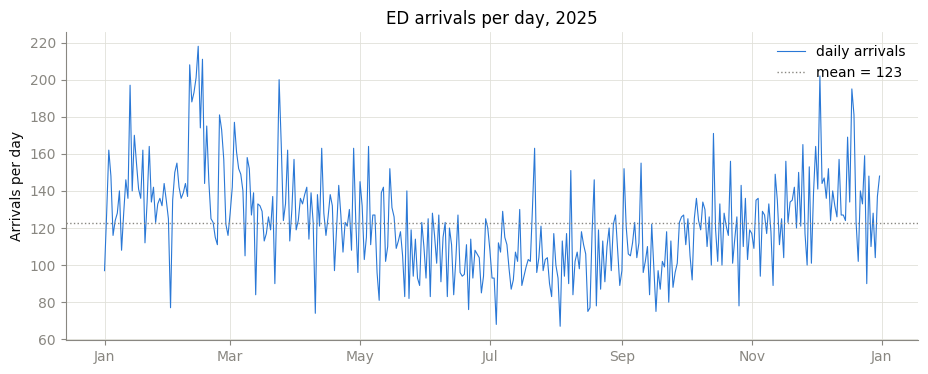

In [5]:
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color=BLUE, linewidth=0.8, label="daily arrivals")
ax.axhline(daily.mean(), color=MUTED, linestyle=":", linewidth=1, label=f"mean = {daily.mean():.0f}")
ax.set_ylabel("Arrivals per day"); ax.set_title("ED arrivals per day, 2025")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False, loc="upper right"); plt.show()

Even at this resolution the winter-high, summer-low shape is visible, and so is a cluster of unusually high days in February. To see the slow pattern more clearly we need to remove the fast one.

### Rolling averages

A **rolling average** replaces each day's value by the mean of a window of days around it. A 7-day window is the natural choice for hospital data because it contains one of each weekday, so the weekly sawtooth cancels out exactly. A longer window (28 days) smooths further and shows the season alone. `center=True` puts the window symmetrically around each day rather than trailing behind it.

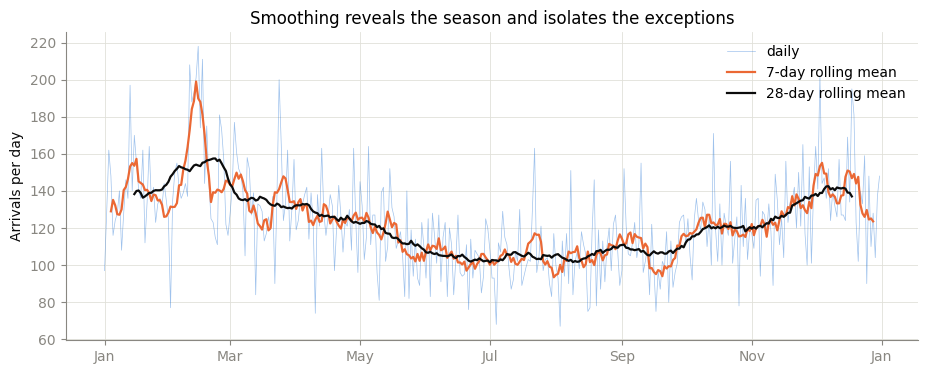

In [6]:
roll7 = daily.rolling(7, center=True).mean()
roll28 = daily.rolling(28, center=True).mean()

fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color=BLUE, linewidth=0.5, alpha=0.45, label="daily")
ax.plot(roll7.index, roll7.values, color=ORANGE, linewidth=1.6, label="7-day rolling mean")
ax.plot(roll28.index, roll28.values, color=INK, linewidth=1.6, label="28-day rolling mean")
ax.set_ylabel("Arrivals per day"); ax.set_title("Smoothing reveals the season and isolates the exceptions")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False, loc="upper right"); plt.show()

**What we see.** The 28-day line is a smooth wave: a peak near the end of January around 140 a day, a trough in July–August near 105, and a rise again into December. That is the **seasonal** component, and clinically it is respiratory illness: influenza, RSV, COVID, pneumonia, all of which peak in winter. Public-health surveillance reports the same curve every year.

The 7-day line follows the season but shows something the 28-day line partly hides: a sharp bump in mid-February that rises well above the seasonal curve and lasts about a week. That bump is the first of the two things we set out to find. We will come back to it in section 4.

Notice also that the raw daily series (faint blue) is *much* noisier than either smoothed line. A single day 20 above or below the trend is unremarkable. Anyone who reacts to one bad day in an ED is reacting to noise.

### Holidays

Public holidays are a special kind of regular event. Let us mark the US federal holidays on the series and zoom into a couple.

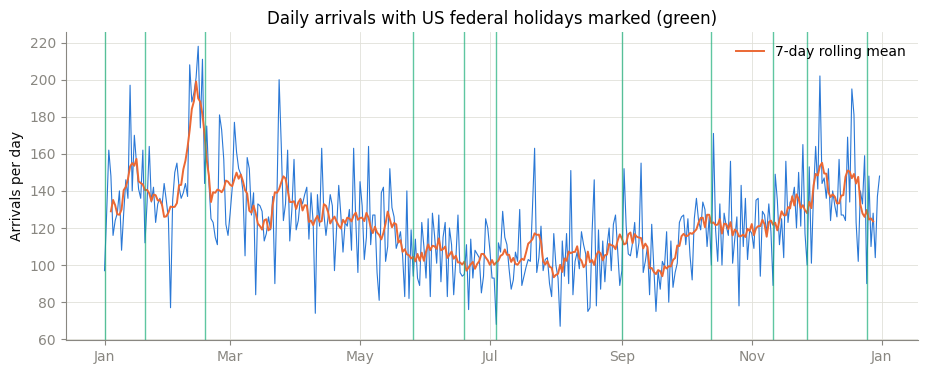

,holiday,day before,holiday,day after,7-day mean
0,2025-01-01,NaN,97,128,NaN
1,2025-01-20,162.0,112,134,140.4
2,2025-02-17,211.0,144,175,170.3
3,2025-05-26,119.0,94,114,104.4
4,2025-06-19,94.0,95,111,101.9
5,2025-07-04,93.0,68,112,101.4
6,2025-09-01,89.0,97,152,114.3
7,2025-10-13,126.0,100,171,122.6
8,2025-11-11,118.0,89,149,121.7
9,2025-11-27,117.0,100,153,128.0


In [7]:
holidays = daily_file.loc[daily_file["holiday"] == 1, "date"]
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color=BLUE, linewidth=0.8)
ax.plot(roll7.index, roll7.values, color=ORANGE, linewidth=1.4, label="7-day rolling mean")
for h in holidays:
    ax.axvline(h, color=AQUA, linewidth=1, alpha=0.7)
ax.set_title("Daily arrivals with US federal holidays marked (green)"); ax.set_ylabel("Arrivals per day")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.legend(frameon=False); plt.show()

around = []
for h in holidays:
    around.append({"holiday": h.date(), "day before": daily.get(h - pd.Timedelta(days=1)), "holiday ": daily.get(h),
                   "day after": daily.get(h + pd.Timedelta(days=1)), "7-day mean": round(roll7.get(h), 1)})
pd.DataFrame(around)

A consistent signature: the holiday itself is quiet (typically 20% below the surrounding trend) and the **day after** is busy (typically 20% above), because the people who waited come in. Thanksgiving and Christmas show it most clearly. This is a *predictable* exception: a good ED staffing plan knows the day after a holiday will be heavy.

## 3. Calendar structure: hour of day and day of week

The weekly sawtooth and the daily curve are **calendar patterns**: they repeat with the calendar. The way to see them is not to plot against time but to *group by the calendar unit* and average. With 365 days, each weekday has about 52 observations, and each hour of the day has 365.

### Hour of day

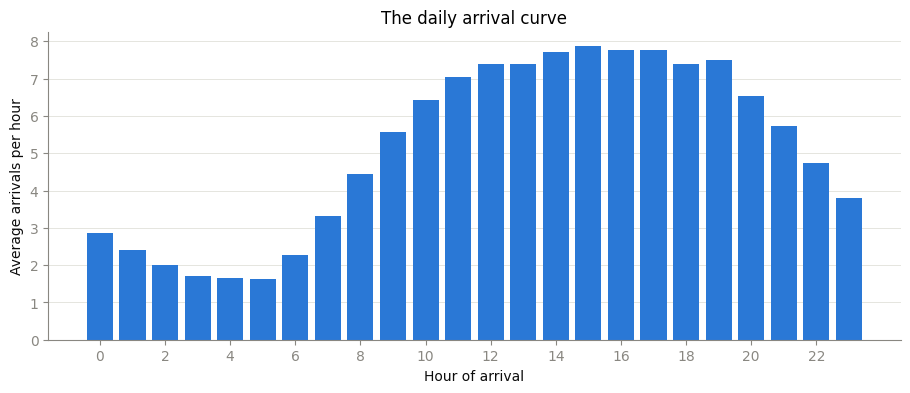

In [8]:
by_hour = visits.groupby("arrival_hour").size() / 365     # average arrivals per hour, per day

fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values, color=BLUE, width=0.8)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of arrival"); ax.set_ylabel("Average arrivals per hour")
ax.set_title("The daily arrival curve"); ax.grid(axis="x", visible=False)
plt.show()

The classic ED arrival curve: a trough around 04:00–05:00 (under 2 an hour), a steep climb through the morning, and a broad plateau from about 11:00 to 20:00 at roughly 7–8 an hour, falling away overnight. Every ED in the world looks like this, and it is the reason ED staffing cannot be flat across the day.

### Day of week

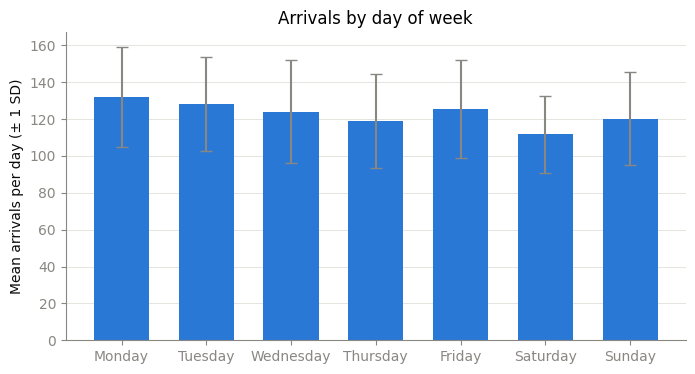

,mean,std
arrival_datetime,,
Monday,131.9,27.2
Tuesday,128.1,25.6
Wednesday,124.0,27.9
Thursday,118.9,25.6
Friday,125.4,26.4
Saturday,111.7,20.8
Sunday,120.3,25.5


In [9]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_wd = daily.groupby(daily.index.day_name()).agg(["mean", "std"]).loc[order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_wd.index, by_wd["mean"], yerr=by_wd["std"], capsize=4, color=BLUE, width=0.65, error_kw=dict(ecolor=MUTED))
ax.set_ylabel("Mean arrivals per day (± 1 SD)"); ax.set_title("Arrivals by day of week"); ax.grid(axis="x", visible=False)
plt.show()
by_wd.round(1)

Monday is the busiest day (about 132) and Saturday the quietest (about 112). The pattern is real and repeats, but look at the error bars: the day-to-day spread *within* a weekday (SD about 25) is larger than the difference *between* weekdays. The weekday effect is a tilt, not a cliff.

### Hour × weekday: a heatmap

Do the two patterns interact? A heatmap of average arrivals by hour and weekday answers it in one picture.

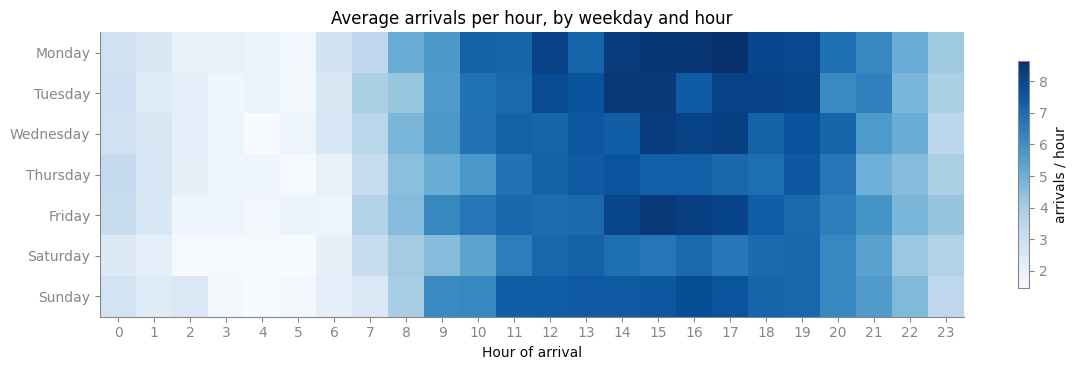

In [10]:
visits["arrival_weekday"] = pd.Categorical(visits["arrival_weekday"], categories=order, ordered=True)
grid = visits.pivot_table(index="arrival_weekday", columns="arrival_hour", values="visit_id", aggfunc="size", observed=True) / 52

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(grid, cmap="Blues", aspect="auto")
ax.set_xticks(range(24)); ax.set_yticks(range(7)); ax.set_yticklabels(grid.index); ax.grid(False)
ax.set_xlabel("Hour of arrival"); ax.set_title("Average arrivals per hour, by weekday and hour")
fig.colorbar(im, ax=ax, shrink=0.8, label="arrivals / hour")
plt.tight_layout(); plt.show()

The daily curve is the same shape every day of the week; Monday is simply a slightly darker version of it. There is a hint that weekend mornings start later. The two calendar patterns are essentially **additive**: the weekday shifts the whole curve up or down, it does not reshape it.

### Arrivals versus waiting: the same clock, a different curve

So far we have looked at *how many* arrive. The tracking board also tells us *how long they wait*. Put the two on the same clock.

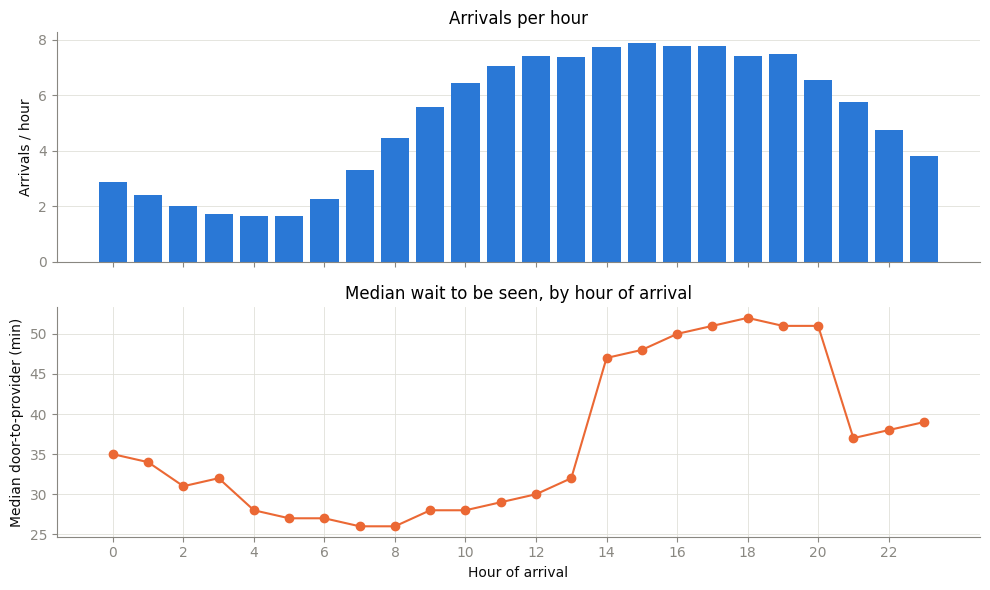

In [11]:
wait_by_hour = visits.groupby("arrival_hour")["door_to_provider_min"].median()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].bar(by_hour.index, by_hour.values, color=BLUE, width=0.8); axes[0].set_ylabel("Arrivals / hour")
axes[0].set_title("Arrivals per hour"); axes[0].grid(axis="x", visible=False)
axes[1].plot(wait_by_hour.index, wait_by_hour.values, color=ORANGE, marker="o", linewidth=1.5)
axes[1].set_ylabel("Median door-to-provider (min)"); axes[1].set_title("Median wait to be seen, by hour of arrival")
axes[1].set_xticks(range(0, 24, 2)); axes[1].set_xlabel("Hour of arrival")
plt.tight_layout(); plt.show()

**This is the most important picture in the session.** Arrivals rise smoothly from 07:00 and plateau by 11:00. The wait does *not* follow: it stays under 30 minutes all morning, then jumps abruptly at 14:00 to around 50 minutes and stays there until 21:00. A jump like that at a fixed clock time is not patient behaviour; it is a **schedule**. Somewhere around 14:00 the department's capacity stops keeping up with its arrivals, most plausibly because a morning provider shift ends and the afternoon is thinner. The arrival curve alone would not have shown this. The lesson: always plot the outcome on the same clock as the demand.

## 4. Something unusual: the week of 10 February

Back to the bump in the smoothed series. First, look at it up close.

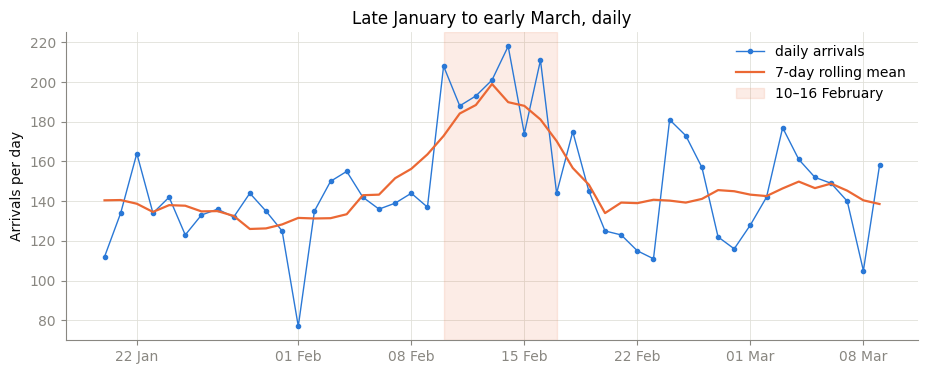

10–16 February: mean 199 arrivals/day, max 218
Rest of February: mean 138 arrivals/day


In [12]:
zoom = daily["2025-01-20":"2025-03-09"]
zoom_roll = roll7["2025-01-20":"2025-03-09"]

fig, ax = plt.subplots()
ax.plot(zoom.index, zoom.values, color=BLUE, marker="o", markersize=3, linewidth=1, label="daily arrivals")
ax.plot(zoom_roll.index, zoom_roll.values, color=ORANGE, linewidth=1.6, label="7-day rolling mean")
ax.axvspan(pd.Timestamp("2025-02-10"), pd.Timestamp("2025-02-16 23:59"), color=ORANGE, alpha=0.12, label="10–16 February")
ax.set_ylabel("Arrivals per day"); ax.set_title("Late January to early March, daily")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b")); ax.legend(frameon=False); plt.show()

week = daily["2025-02-10":"2025-02-16"]
rest_feb = daily["2025-02-01":"2025-02-28"].drop(week.index)
print(f"10–16 February: mean {week.mean():.0f} arrivals/day, max {week.max()}")
print(f"Rest of February: mean {rest_feb.mean():.0f} arrivals/day")

Seven consecutive days far above the surrounding level: the week averages close to 200 arrivals a day against a February norm of about 140 that was already the seasonal peak, and one day passes 210. No weekday effect or holiday explains a full week.

### How unusual is unusual? Three yardsticks

Time series are noisy, so "high" needs a yardstick, and it turns out that *which* yardstick matters. Start with the obvious one: compare each **day** with the seasonal level (the 28-day rolling mean) and express the difference in units of the typical day-to-day scatter.

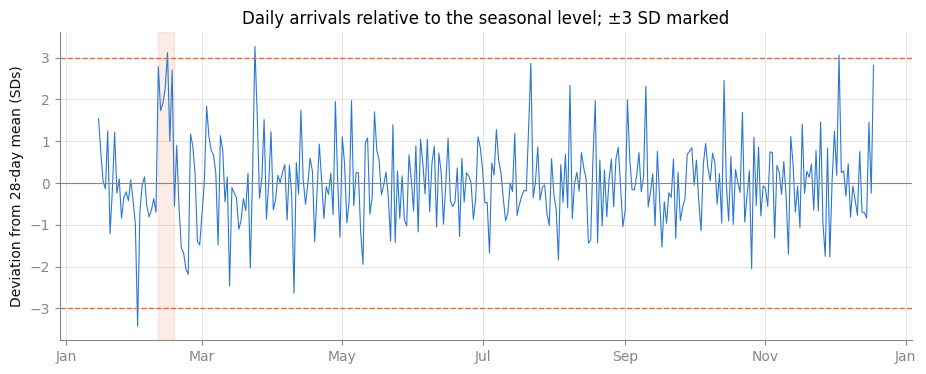

Days more than 2.5 SD above the seasonal level:
arrival_datetime
2025-02-10    2.8
2025-02-14    3.1
2025-02-16    2.7
2025-03-24    3.3
2025-07-22    2.9
2025-12-03    3.1
2025-12-18    2.8


In [13]:
resid = daily - roll28                       # what is left after removing the seasonal level
z = resid / resid.std()

fig, ax = plt.subplots()
ax.plot(z.index, z.values, color=BLUE, linewidth=0.8)
ax.axhline(3, color=ORANGE, linestyle="--", linewidth=1); ax.axhline(-3, color=ORANGE, linestyle="--", linewidth=1)
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.axvspan(pd.Timestamp("2025-02-10"), pd.Timestamp("2025-02-16 23:59"), color=ORANGE, alpha=0.12)
ax.set_ylabel("Deviation from 28-day mean (SDs)"); ax.set_title("Daily arrivals relative to the seasonal level; ±3 SD marked")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); plt.show()

print("Days more than 2.5 SD above the seasonal level:")
print(z[z > 2.5].round(1).to_string())

This is instructive precisely because it *fails* to single the week out. Three of its days are 2.5–3 SD high, but so are a day in March, one in July and two in December: ordinary busy days at the edge of the noise. Judged one day at a time, the February week is not obviously special. A single day is a weak witness.

The second yardstick changes the **time unit**. Sum arrivals by week and compare each week with the level of the weeks around it (a 9-week rolling median, which a single extreme week cannot drag).

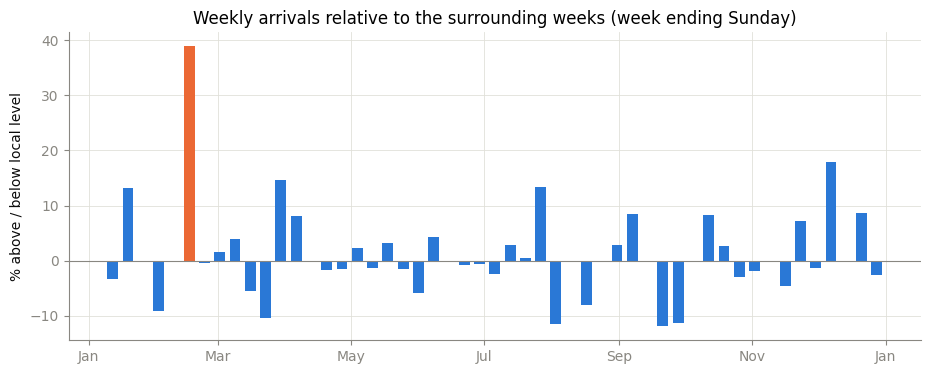

Largest weekly deviations:
arrival_datetime
2025-02-16    38.9
2025-12-07    18.0
2025-03-30    14.6
2025-07-27    13.4


In [14]:
weekly_full = daily.resample("W").sum()[1:-1]                        # drop the partial first and last weeks
local_level = weekly_full.rolling(9, center=True, min_periods=5).median()
weekly_dev = (weekly_full / local_level - 1) * 100

fig, ax = plt.subplots()
colors = [ORANGE if d > 25 else BLUE for d in weekly_dev]
ax.bar(weekly_dev.index, weekly_dev.values, width=5, color=colors)
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.set_ylabel("% above / below local level"); ax.set_title("Weekly arrivals relative to the surrounding weeks (week ending Sunday)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); plt.show()

print("Largest weekly deviations:")
print(weekly_dev.sort_values(ascending=False).head(4).round(1).to_string())

Now there is no ambiguity. The week ending 16 February sits about 39% above its neighbours; the next-largest week of the year is under 20%, and the typical week is within about ±7%. Aggregating to the week averaged away the daily noise and left the sustained surge standing alone.

The third yardstick stays at the daily scale but asks a different question: not *how high* is any one day, but *how many days in a row* are above the seasonal level. Under pure noise, each day is above or below the trend like a coin toss, so a run of seven above in a row happens by chance less than once in a hundred tries.

In [15]:
above = (resid > 0).astype(int)
run_id = (above != above.shift()).cumsum()
run_len = above.groupby(run_id).transform("size") * above          # length of the run each day belongs to (0 if below)

print("Longest runs of consecutive days above the seasonal level:", sorted(int(x) for x in run_len.groupby(run_id).max().unique())[-4:])
print("Days belonging to a run of 7 or more:")
print(daily[run_len >= 7].to_string())

Longest runs of consecutive days above the seasonal level: [4, 5, 6, 7]
Days belonging to a run of 7 or more:
arrival_datetime
2025-02-10    208
2025-02-11    188
2025-02-12    193
2025-02-13    201
2025-02-14    218
2025-02-15    174
2025-02-16    211
Freq: D


The only run of seven or more consecutive above-trend days in the entire year is 10–16 February. This is one of the classic **run rules** of statistical process control: a point beyond 3 SD says "something happened today"; seven in a row on the same side says "something has been happening all week", and the second kind of signal is often the more important one in a hospital.

In quality-improvement language, this week is a **special cause**: a specific, identifiable event, as opposed to the **common-cause** variation that produces the ordinary scatter. And the lesson about yardsticks is general: a sustained shift is invisible to a test designed for spikes. Choose the time unit and the rule to match the kind of change you are looking for.

### What happened to the department that week?

Volume is only the input. The daily file lets us see what the surge did to waiting, crowding and leaving.

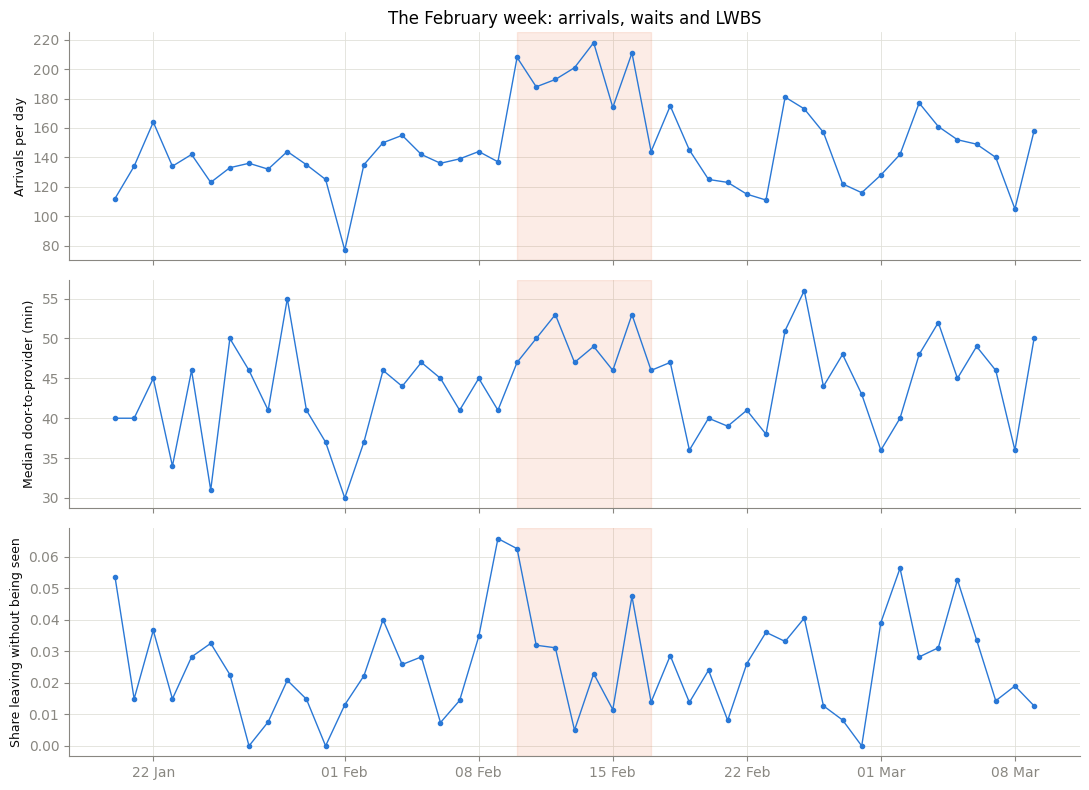

            visits  median_door_to_provider_min  p90_door_to_provider_min  \
date                                                                        
2025-02-10     208                         47.0                     117.0   
2025-02-11     188                         50.0                     108.0   
2025-02-12     193                         53.0                     128.0   
2025-02-13     201                         47.0                     107.0   
2025-02-14     218                         49.0                     137.0   
2025-02-15     174                         46.0                     101.0   
2025-02-16     211                         53.0                     118.0   

            lwbs_rate  admissions  
date                               
2025-02-10      0.062          33  
2025-02-11      0.032          26  
2025-02-12      0.031          36  
2025-02-13      0.005          33  
2025-02-14      0.023          41  
2025-02-15      0.012          33  
2025-02-16      0.

In [16]:
df = daily_file.set_index("date")
cols = {"visits": "Arrivals per day", "median_door_to_provider_min": "Median door-to-provider (min)",
        "lwbs_rate": "Share leaving without being seen"}
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (c, label) in zip(axes, cols.items()):
    s = df[c]["2025-01-20":"2025-03-09"]
    ax.plot(s.index, s.values, color=BLUE, marker="o", markersize=3, linewidth=1)
    ax.axvspan(pd.Timestamp("2025-02-10"), pd.Timestamp("2025-02-16 23:59"), color=ORANGE, alpha=0.12)
    ax.set_ylabel(label, fontsize=9)
axes[0].set_title("The February week: arrivals, waits and LWBS"); axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); plt.show()

week_rows = df.loc["2025-02-10":"2025-02-16", ["visits", "median_door_to_provider_min", "p90_door_to_provider_min", "lwbs_rate", "admissions"]]
rest = df.loc["2025-02"].drop(week_rows.index)
print(week_rows.round(3))
print()
print(f"Rest of February, mean: median wait {rest['median_door_to_provider_min'].mean():.0f} min, "
      f"P90 wait {rest['p90_door_to_provider_min'].mean():.0f} min, LWBS {rest['lwbs_rate'].mean():.1%}")

The surge in arrivals produced longer waits, especially at the 90th percentile, and a higher share of patients leaving without being seen on the worst days. That is the mechanism the tracking board exists to make visible: crowding degrades care, and it does so within hours, not weeks. The clinical interpretation is a winter storm combined with the influenza peak, and the operational lesson is that a department needs a surge plan that can be triggered from the numbers, not from the mood on the floor.

## 5. Something changed: 1 July

The second thing to find is not a spike but a **step**: a permanent change in level at a point in time. Steps are harder to see than spikes because they are gradual in the smoothed line and because other things change at the same time. The way to find one is to plot the right measure, for the right group, with a smoother, and look for a level that differs before and after.

The measure is the daily median wait to be seen. But for whom? Try everyone first.

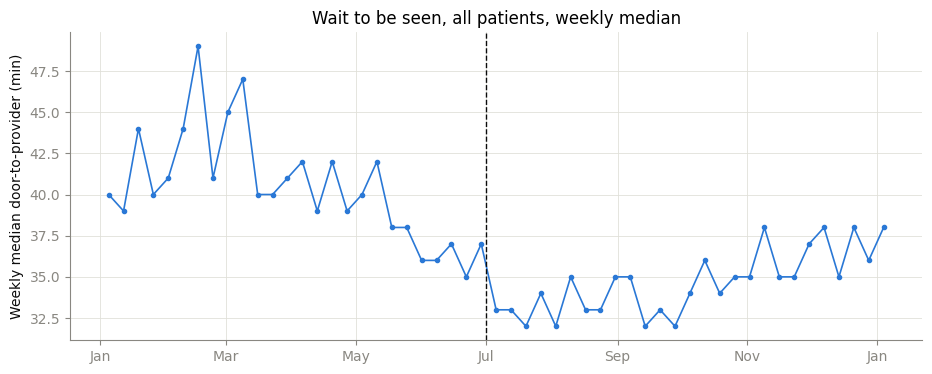

In [17]:
wk = ts.resample("W")["door_to_provider_min"].median()

fig, ax = plt.subplots()
ax.plot(wk.index, wk.values, color=BLUE, marker="o", markersize=3, linewidth=1.2)
ax.axvline(pd.Timestamp("2025-07-01"), color=INK, linestyle="--", linewidth=1)
ax.set_ylabel("Weekly median door-to-provider (min)"); ax.set_title("Wait to be seen, all patients, weekly median")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); plt.show()

There is a visible drop at the dashed line. But look at the months before it: the series had already been falling steadily since the February peak. Waits track volume, volume falls through spring and summer, and the drop at 1 July sits on top of that slope. How much of it is the fast track and how much is simply summer? A single series cannot say. To make the step *attributable* we need two things: the group the change was meant to affect, and a **comparison group** that it was not.

The department's fast-track area opened on 1 July for ESI 4–5 patients. Split the series by acuity.

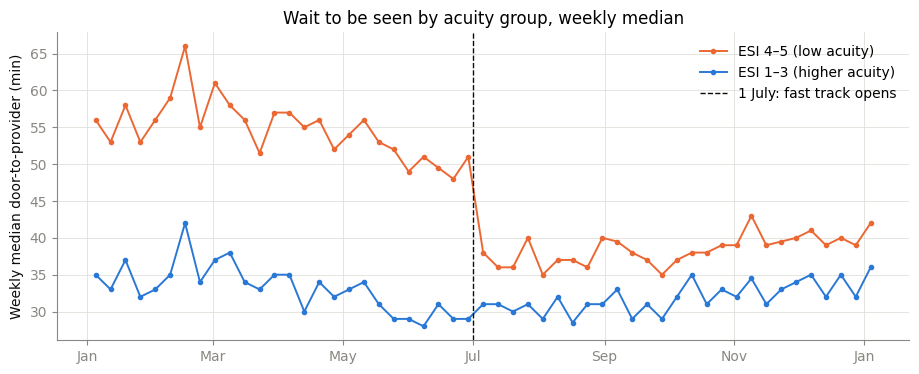

ESI 4–5: median wait 55 min before 1 July -> 39 min after  (change -16)
ESI 1–3: median wait 33 min before 1 July -> 32 min after  (change -1)


In [18]:
low = ts[ts["esi_level"] >= 4].resample("W")["door_to_provider_min"].median()
high = ts[ts["esi_level"] <= 3].resample("W")["door_to_provider_min"].median()

fig, ax = plt.subplots()
ax.plot(low.index, low.values, color=ORANGE, marker="o", markersize=3, linewidth=1.4, label="ESI 4–5 (low acuity)")
ax.plot(high.index, high.values, color=BLUE, marker="o", markersize=3, linewidth=1.4, label="ESI 1–3 (higher acuity)")
ax.axvline(pd.Timestamp("2025-07-01"), color=INK, linestyle="--", linewidth=1, label="1 July: fast track opens")
ax.set_ylabel("Weekly median door-to-provider (min)"); ax.set_title("Wait to be seen by acuity group, weekly median")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.legend(frameon=False); plt.show()

pre, post = ts[:"2025-06-30"], ts["2025-07-01":]
for lab, m in [("ESI 4–5", lambda x: x["esi_level"] >= 4), ("ESI 1–3", lambda x: x["esi_level"] <= 3)]:
    a, b = pre[m(pre)]["door_to_provider_min"].median(), post[m(post)]["door_to_provider_min"].median()
    print(f"{lab}: median wait {a:.0f} min before 1 July -> {b:.0f} min after  (change {b - a:+.0f})")

Now the step is unmistakable and, more importantly, attributable. The low-acuity line drops by about 15 minutes at the dashed line and stays down for the rest of the year, at a level it never reached before July even in the quiet weeks of June. The higher-acuity line shows only the gentle seasonal slope, with no step at all. Whatever happened on 1 July happened to ESI 4–5 patients and to nobody else, which is exactly what a fast track for ESI 4–5 patients should do.

This is the logic of a **comparison group**. The fast track was designed for ESI 4–5 patients; if it works, their waits should fall and other patients' waits should not. Seeing exactly that pattern, at exactly the date of the change, is far stronger evidence than a before/after difference on its own, because seasonality, volume and everything else that changed over the summer affected both groups alike.

### The outcome that matters: leaving without being seen

Waiting is the mechanism; leaving is the harm. LWBS is rare, so use a longer window: a 4-week rolling rate, by acuity group.

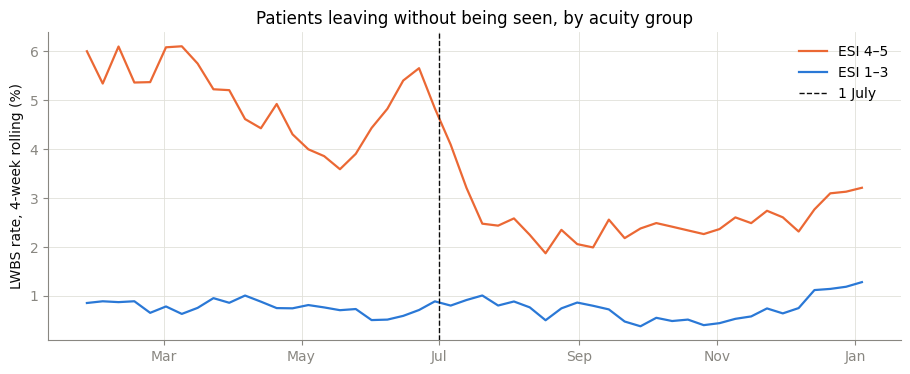

ESI 4–5: LWBS 5.0% before -> 2.5% after
ESI 1–3: LWBS 0.8% before -> 0.8% after


In [19]:
def lwbs_series(frame):
    weekly_n = frame.resample("W").size()
    weekly_l = frame[frame["disposition"] == "LWBS"].resample("W").size().reindex(weekly_n.index, fill_value=0)
    return (weekly_l.rolling(4).sum() / weekly_n.rolling(4).sum()) * 100

lw_low = lwbs_series(ts[ts["esi_level"] >= 4])
lw_high = lwbs_series(ts[ts["esi_level"] <= 3])

fig, ax = plt.subplots()
ax.plot(lw_low.index, lw_low.values, color=ORANGE, linewidth=1.6, label="ESI 4–5")
ax.plot(lw_high.index, lw_high.values, color=BLUE, linewidth=1.6, label="ESI 1–3")
ax.axvline(pd.Timestamp("2025-07-01"), color=INK, linestyle="--", linewidth=1, label="1 July")
ax.set_ylabel("LWBS rate, 4-week rolling (%)"); ax.set_title("Patients leaving without being seen, by acuity group")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.legend(frameon=False); plt.show()

for lab, m in [("ESI 4–5", lambda x: x["esi_level"] >= 4), ("ESI 1–3", lambda x: x["esi_level"] <= 3)]:
    a = (pre[m(pre)]["disposition"] == "LWBS").mean(); b = (post[m(post)]["disposition"] == "LWBS").mean()
    print(f"{lab}: LWBS {a:.1%} before -> {b:.1%} after")

The LWBS rate for low-acuity patients falls by roughly a third after July and stays down, while the higher-acuity rate is flat and low throughout. The February surge is visible as a bump in the low-acuity line: the same patients who leave when the fast track is absent are the ones who left when the department was overwhelmed.

A caution that belongs in every before/after analysis: what we have shown is that a change in the series coincides with the date of an intervention, for the intended group and not for the comparison group. That is good evidence. It is not proof that nothing else happened to ESI 4–5 patients on 1 July, and a real evaluation would ask the department what else changed that day.

## 6. Two series together: boarding and hospital occupancy

A last pattern, and a different kind of question: not *when* did something happen, but *what moves with what*. Boarding (admitted patients waiting in the ED for a bed) is widely believed to depend on how full the hospital is. Two daily series, plotted one above the other on the same time axis.

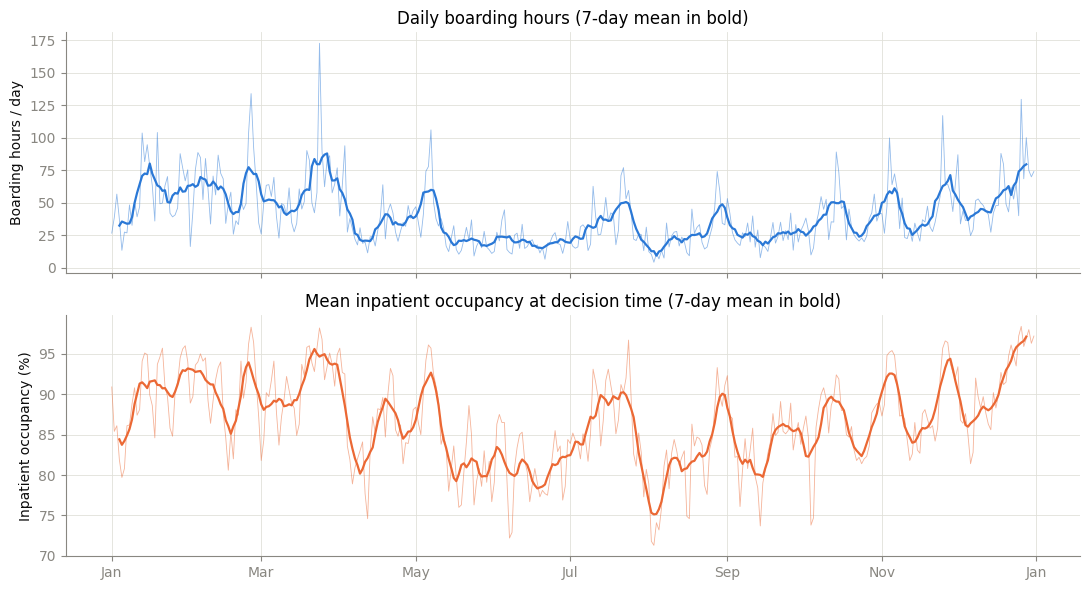

Correlation between daily boarding hours and occupancy: r = 0.81


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
b = df["boarding_hours"]; o = df["mean_inpatient_occupancy_pct"]
axes[0].plot(b.index, b.values, color=BLUE, linewidth=0.6, alpha=0.5)
axes[0].plot(b.index, b.rolling(7, center=True).mean().values, color=BLUE, linewidth=1.6)
axes[0].set_ylabel("Boarding hours / day"); axes[0].set_title("Daily boarding hours (7-day mean in bold)")
axes[1].plot(o.index, o.values, color=ORANGE, linewidth=0.6, alpha=0.5)
axes[1].plot(o.index, o.rolling(7, center=True).mean().values, color=ORANGE, linewidth=1.6)
axes[1].set_ylabel("Inpatient occupancy (%)"); axes[1].set_title("Mean inpatient occupancy at decision time (7-day mean in bold)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout(); plt.show()

print(f"Correlation between daily boarding hours and occupancy: r = {b.corr(o):.2f}")

The two lines rise and fall together: high occupancy in winter and on weekdays, high boarding at the same times, and the same short-term wobbles. A correlation of about 0.8 between two daily series is very strong. The operational reading is the one every ED director knows: **boarding is a hospital problem that shows up in the ED**. The ED cannot fix it by working faster; the wards have to discharge earlier.

Two things to keep in mind when reading two series together. First, we drew them on **two panels with a shared time axis**, not on one panel with two y-axes; two y-axes can be rescaled to make any pair of lines look related. Second, two series that share a season will correlate because of the season alone; a fairer test looks at the correlation of the *residuals* after removing the seasonal level from each, which is a good exercise.

## Summary: how to read a time series

| Step | Tool | What it showed here |
|---|---|---|
| Choose the time unit | `set_index` + `resample` | Hours are noise, months hide everything; days are the working unit |
| Separate slow from fast | `rolling(7)`, `rolling(28)` | Winter–summer season; a February bump the 28-day line hides and the 7-day line reveals |
| Find the calendar patterns | `groupby` hour / weekday; heatmap | Daily arrival curve; Monday tilt; the two combine additively |
| Put demand and outcome on the same clock | two panels, same x | Waits jump at 14:00 while arrivals do not: a staffing signal |
| Judge unusual against a yardstick | daily ±3 SD; weekly deviation; run rule | Single days are ambiguous; the week of 10 February is the only run of 7 and the only week ~40% above its neighbours |
| Look for steps with a comparison group | split series by group, mark the date | Fast track cut ESI 4–5 waits by ~15 min and LWBS by a third; ESI 1–3 unchanged |
| Read two series together | stacked panels, correlation | Boarding follows hospital occupancy (r ≈ 0.8) |

Three habits. **Smooth before you judge**: single days are noise. **Mark what you know happened** (holidays, interventions) before searching for what you don't. And **never evaluate a change without a comparison group**: the summer would have taken credit for the fast track.